In [48]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [49]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  # TODO write code to implement the ReLU and compute the activation at the
  # hidden unit from the preactivation
  # This should work on every element of the ndarray "preactivation" at once
  # One way to do this is with the ndarray "maximum" function
  activation = np.maximum(0, preactivation)
  return activation

Se utiliza np.maximum(0, preactivation) porque la función ReLU está definida matemáticamente como ReLU(z)=max(0,z). Esto significa que, para cada valor de entrada, si el valor es negativo devuelve 0, y si es positivo o igual a cero devuelve el mismo valor. La función np.maximum() de NumPy realiza esta comparación de manera vectorizada, es decir, procesa todos los elementos del arreglo al mismo tiempo sin necesidad de utilizar ciclos for.

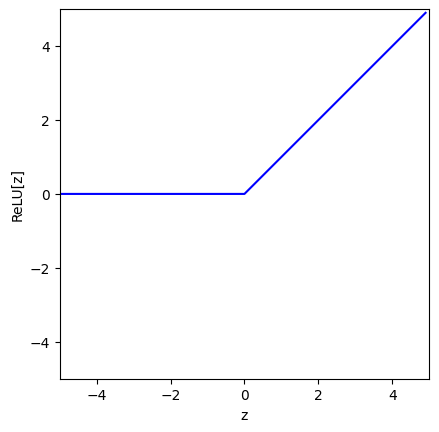

In [50]:
# Make an array of inputs
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
fig, ax = plt.subplots()
ax.plot(z,RelU_z,'b-')
ax.set_xlim([-5,5]);ax.set_ylim([-5,5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU[z]')
ax.set_aspect('equal')
plt.show()

In [51]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # TODO Replace the code below to compute the three initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x

  # Pass these through the ReLU function to compute the activations as in
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # TODO Replace the code below to weight the activations using phi1, phi2 and phi3
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  # TODO Replace the code below to combining the weighted activations and add
  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

Primero se calculan las preactivaciones (pre_1, pre_2 y pre_3) mediante una combinación lineal de la entrada x, utilizando un sesgo (θi0) y un peso (θi1). Posteriormente, cada preactivación pasa por la función ReLU para obtener las activaciones de las neuronas ocultas. Después, cada activación se multiplica por su correspondiente peso de salida (ϕ1, ϕ2 y ϕ3), lo que representa la contribución de cada neurona al resultado final. Finalmente, se suman estas contribuciones junto con el sesgo de salida (ϕ0) para obtener la salida de la red neuronal. Este procedimiento sigue la arquitectura de una red neuronal superficial de una entrada, tres neuronas ocultas y una salida.

In [52]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

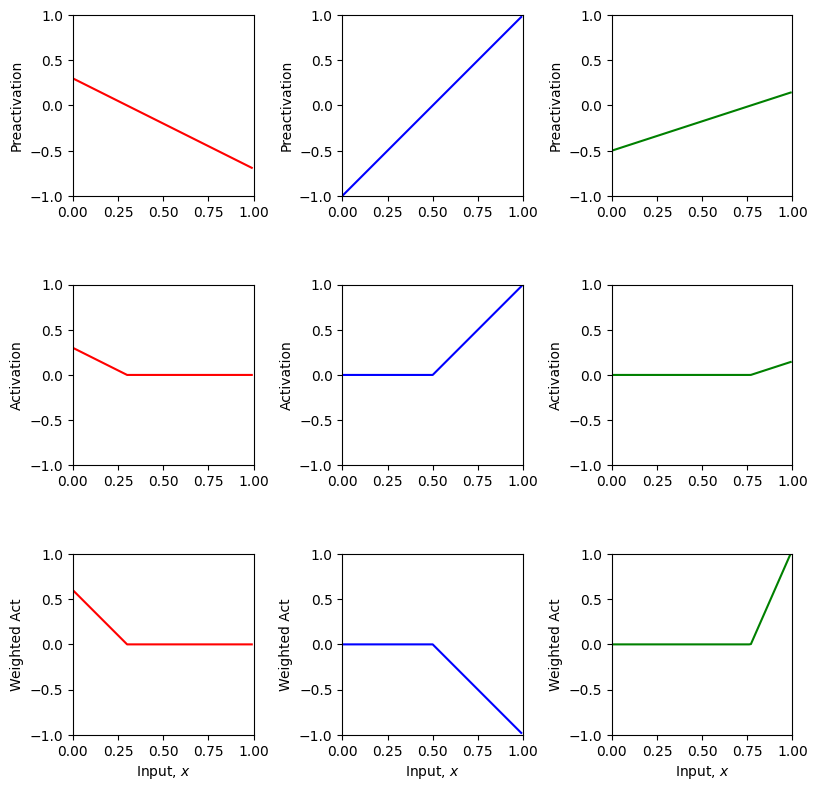

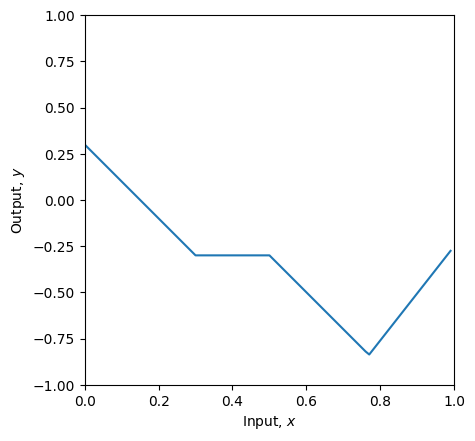

In [53]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

Now let's play with the parameters to make sure we understand how they work.

$\theta_{10} =  0.3$ ; $\theta_{11} = -1.0$<br>
$\theta_{20} =  -1.0$ ; $\theta_{21} = 2.0$<br>
$\theta_{30} =  -0.5$ ; $\theta_{31} = 0.65$<br>
$\phi_0 = -0.3; \phi_1 = 2.0; \phi_2 = -1.0; \phi_3 = 7.0$

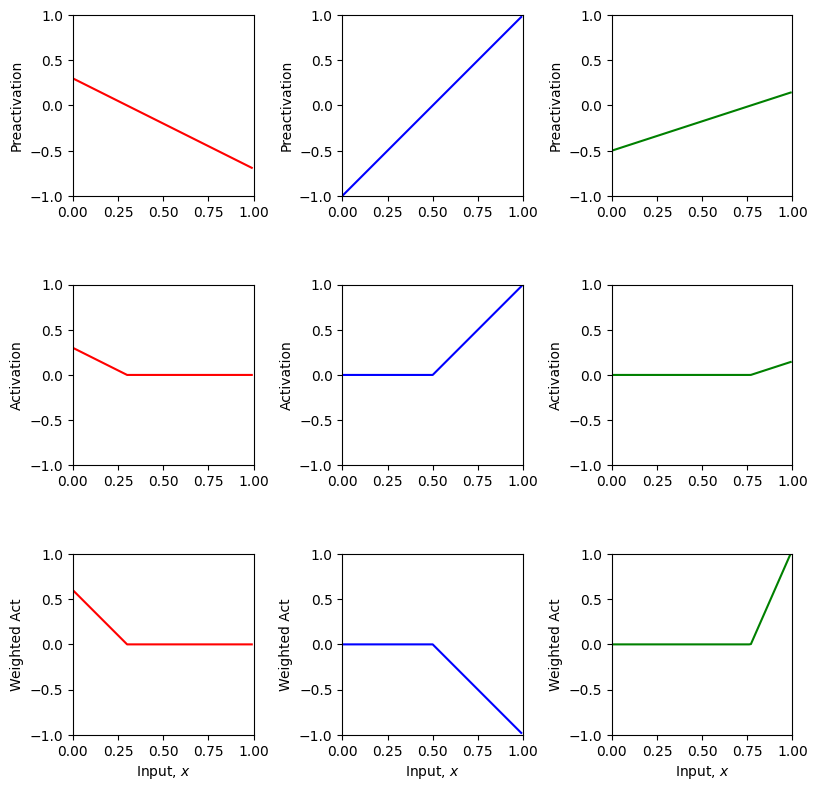

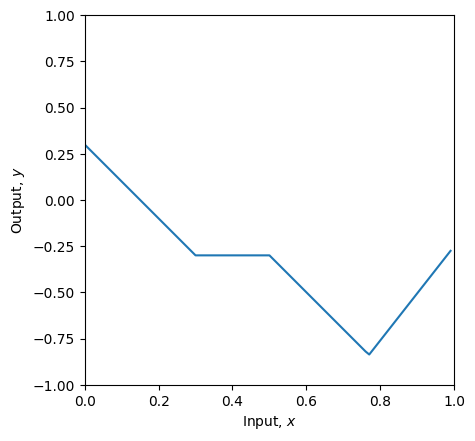

In [54]:
# TODO
# 1. Predict what effect changing phi_0 will have on the network.

# 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct

# 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.

# 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.

# 5. Change the parameters so that there are only two "joints" (including outside the range of the plot)
# There are actually three ways to do this.

# 6. With the original parameters, the second line segment is flat (i.e. has slope zero)
# How could you change theta_10 so that all of the segments have non-zero slopes

# 7. What do you predict would happen if you multiply theta_20 and theta21 by 0.5, and phi_2 by 2.0?
# Check if you are correct.

# 8. What do you predict would happen if you multiply theta_20 and theta21 by -0.5, and phi_2 by -2.0?
# Check if you are correct.

theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

### 1. Predict what effect changing phi_0 will have on the network.

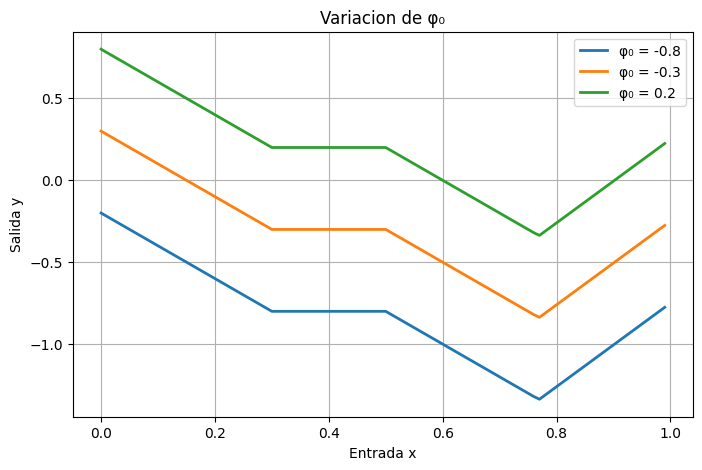

In [55]:
# 1. Predict what effect changing phi_0 will have on the network.

# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

# Valores de entrada
x = np.arange(0, 1, 0.01)

# Distintos valores para el bias de salida
phi0_values = [-0.8, -0.3, 0.2]

plt.figure(figsize=(8,5))

for phi_0 in phi0_values:

    y, *_ = shallow_1_1_3(
        x, ReLU,
        phi_0, phi_1, phi_2, phi_3,
        theta_10, theta_11,
        theta_20, theta_21,
        theta_30, theta_31
    )

    plt.plot(x, y, linewidth=2, label=f'φ₀ = {phi_0}')

plt.title("Variacion de φ₀")
plt.xlabel("Entrada x")
plt.ylabel("Salida y")
plt.grid(True)
plt.legend()
plt.show()

### 1. Predict what effect changing phi_0 will have on the network.

phi_0 es el bias de salida. Cambiarlo desplaza toda la gráfica hacia arriba o hacia abajo sin modificar su forma.

Ya que se suma al resultado final:

**y = ϕ0 + ϕ1h1 + ϕ2h2 + ϕ3h3**

Si se aumenta phi_0, toda la curva sube la misma cantidad. Si disminuyes phi_0, toda la curva baja.



### 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct

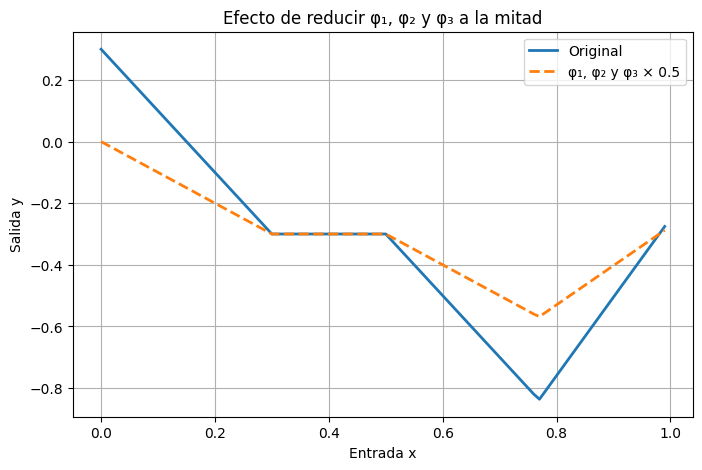

In [56]:
# 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct

# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0


x = np.arange(0, 1, 0.01) # Entrada

# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

# Red con phi1, phi2 y phi3 reducidos a la mitad
y_half, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0,
    phi_1 * 0.5,
    phi_2 * 0.5,
    phi_3 * 0.5,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)


plt.figure(figsize=(8,5))

plt.plot(x, y_original, linewidth=2, label='Original')
plt.plot(x, y_half, '--', linewidth=2, label='φ₁, φ₂ y φ₃ × 0.5')

plt.title('Efecto de reducir φ₁, φ₂ y φ₃ a la mitad')
plt.xlabel('Entrada x')
plt.ylabel('Salida y')
plt.grid(True)
plt.legend()

plt.show()


### 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct

La forma general permanece igual, pero la contribución de cada neurona oculta se reduce a la mitad.
Cada activación se multiplica por su correspondiente peso:

**w_act_1 = phi_1 * act_1**

Si todos esos pesos valen la mitad, todas las pendientes producidas por las neuronas también se reducen a la mitad.


### 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.

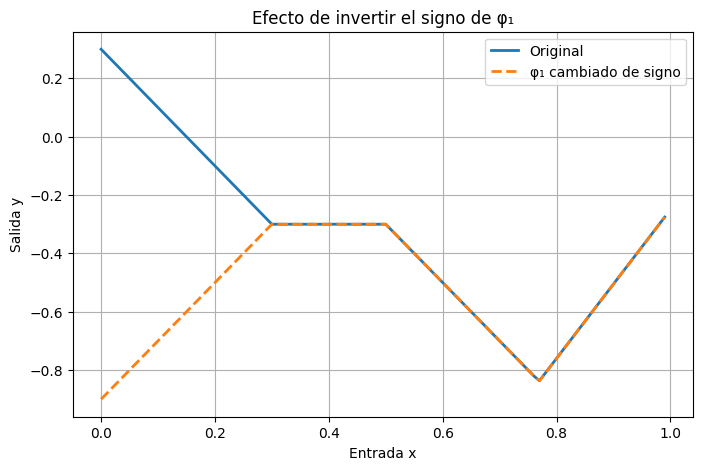

In [57]:
# 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

# Valores de entrada
x = np.arange(0, 1, 0.01)

# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

# Red con phi_1 invertido
y_invertida, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0,
    -phi_1,      #phi-1
    phi_2,
    phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)


plt.figure(figsize=(8,5))

plt.plot(x, y_original, linewidth=2, label='Original')
plt.plot(x, y_invertida, '--', linewidth=2,
         label='φ₁ cambiado de signo')

plt.title('Efecto de invertir el signo de φ₁')
plt.xlabel('Entrada x')
plt.ylabel('Salida y')
plt.grid(True)
plt.legend()

plt.show()


### 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.

La contribución de la primera neurona se invierte.

Antes:
**ϕ1h1**
	​
Después:
**−ϕ1h1**
La parte de la curva que antes aumentaba ahora disminuye.

### 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.

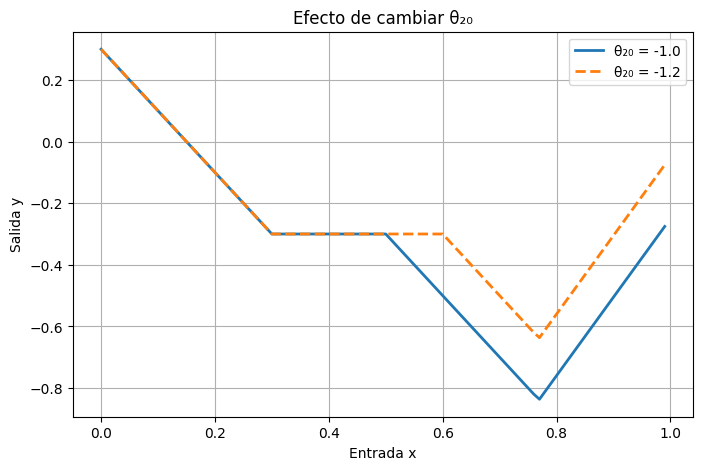

In [58]:
### 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

x = np.arange(0,1,0.01)

# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

# Cambiando theta_20
y_modificada, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -1.2, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x, y_original, label='θ₂₀ = -1.0', linewidth=2)
plt.plot(x, y_modificada, '--', label='θ₂₀ = -1.2', linewidth=2)

plt.title("Efecto de cambiar θ₂₀")
plt.xlabel("Entrada x")
plt.ylabel("Salida y")
plt.grid(True)
plt.legend()

plt.show()

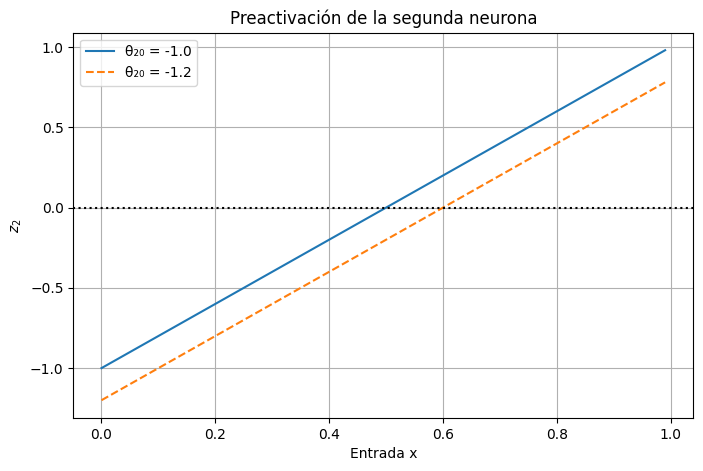

In [59]:
# Obtener las preactivaciones

_, _, pre2_original, _, _, _, _, _, _, _ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -1.0, theta_21,
    theta_30, theta_31
)

_, _, pre2_modificada, _, _, _, _, _, _, _ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -1.2, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x, pre2_original, label='θ₂₀ = -1.0')
plt.plot(x, pre2_modificada, '--', label='θ₂₀ = -1.2')

plt.axhline(0, color='black', linestyle=':')

plt.title("Preactivación de la segunda neurona")
plt.xlabel("Entrada x")
plt.ylabel("$z_2$")
plt.grid(True)
plt.legend()

plt.show()

En la segunda gráfica se ve claramente que la recta

**z2 = θ20 + θ21x**

se desplaza hacia abajo cuando se cambia  **θ20 de -1.0 a -1.2.**

Como la ReLU solo comienza a activarse cuando

z2>0, el punto donde la recta cruza el eje horizontal cambia de:

**−1+2x=0**

**x=0.5**

a

**−1.2+2x=0**
**x=0.6**

Es decir, la segunda neurona empieza a activarse en x=0.6 en lugar de x=0.5. Por ello, el joint también se desplaza hacia la derecha.

### 5. Change the parameters so that there are only two "joints" (including outside the range of the plot)

####5.1. Desactivar completamente una neurona (por ejemplo haciendo que nunca active ReLU).

Como
**z2 =θ20 +θ21x**

si elegimos un sesgo negativo, por ejemplo:

**theta_20 = -3**

entonces

**z2<0**

para todo 0 ≤ x ≤ 1, por lo que

**ReLU (z2)=0**

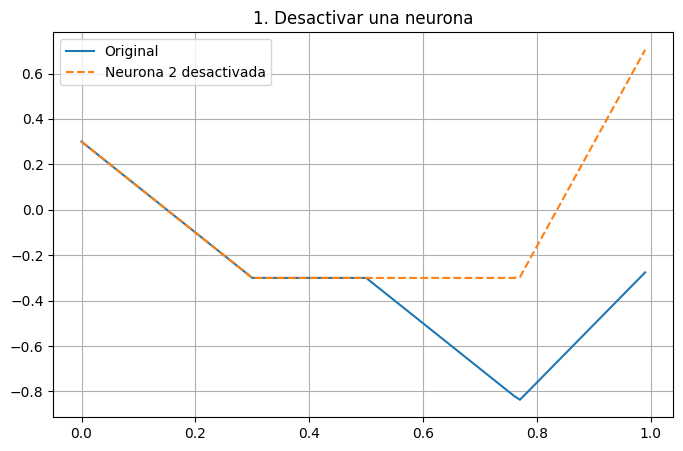

In [60]:
# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -1.0, theta_21,
    theta_30, theta_31
)

# Segunda neurona desactivada
y_sin2, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -3.0, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x,y_original,label="Original")
plt.plot(x,y_sin2,'--',label="Neurona 2 desactivada")

plt.grid()
plt.legend()
plt.title("1. Desactivar una neurona")
plt.show()

####5.2 Hacer que dos neuronas tengan exactamente el mismo punto de activación.
Actualmente los joints están en

**Neurona 1:**

0.3−x=0

Por lo tanto

x=0.3

**Neurona 2:**

−1+2x=0

Por lo tanto

x=0.5

**Neurona 3:**

−0.5+0.65x=0

x≈0.769

Podemos hacer que la neurona 2 también active en 0.3.

Como

θ20 + 2(0.3) = 0

obtenemos

θ20=−0.6

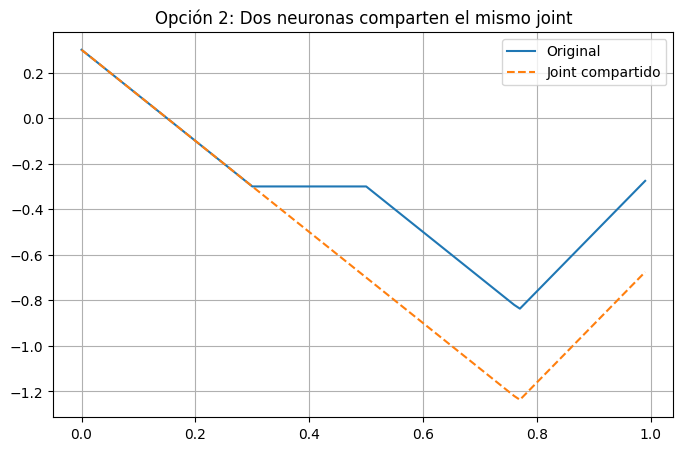

In [61]:
# Neuronas 1 y 2 activan en el mismo punto
y_dosjoints, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -0.6, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x,y_original,label="Original")
plt.plot(x,y_dosjoints,'--',label="Joint compartido")

plt.grid()
plt.legend()
plt.title("Opción 2: Dos neuronas comparten el mismo joint")
plt.show()

####5.3 Mover un joint fuera del intervalo
**0 ≤ x ≤ 1**.

Mover el joint de la segunda neurona a

x = 1.5

Como

θ20 + 2(1.5) = 0

entonces

θ20=−3

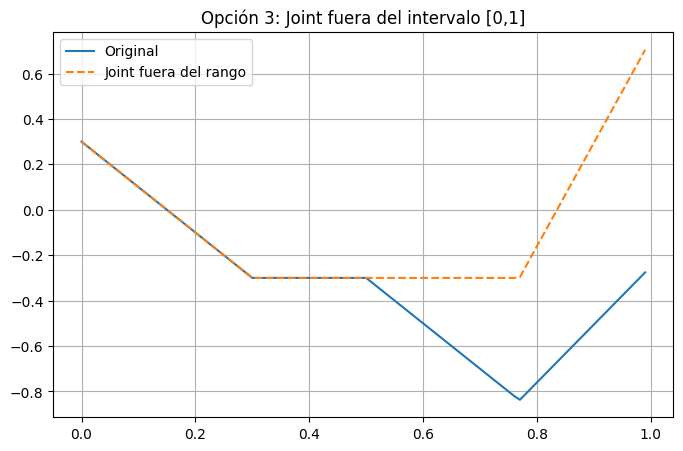

In [62]:
# Joint fuera del rango visible
y_fuera, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    -3.0, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x,y_original,label="Original")
plt.plot(x,y_fuera,'--',label="Joint fuera del rango")

plt.grid()
plt.legend()
plt.title("Opción 3: Joint fuera del intervalo [0,1]")
plt.show()

#### 6. With the original parameters, the second line segment is flat (i.e. has slope zero)
#### How could you change theta_10 so that all of the segments have non-zero slopes
Modificando theta_10 se mueve el punto donde activa la primera neurona.

Por ejemplo:

**theta_10 = 0.1**

**theta_10 = 0.45**

se desplaza ese "joint", haciendo que ya no coincida con los otros y que todos los segmentos tengan pendiente distinta de cero.

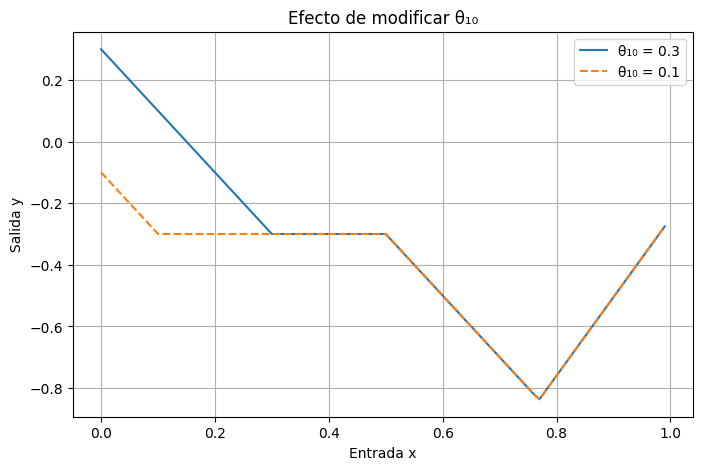

In [63]:
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

x = np.arange(0,1,0.01)

# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

# Cambiando únicamente theta_10
y_modificada, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    0.1, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x,y_original,label='θ₁₀ = 0.3')
plt.plot(x,y_modificada,'--',label='θ₁₀ = 0.1')

plt.title("Efecto de modificar θ₁₀")
plt.xlabel("Entrada x")
plt.ylabel("Salida y")
plt.grid(True)
plt.legend()

plt.show()

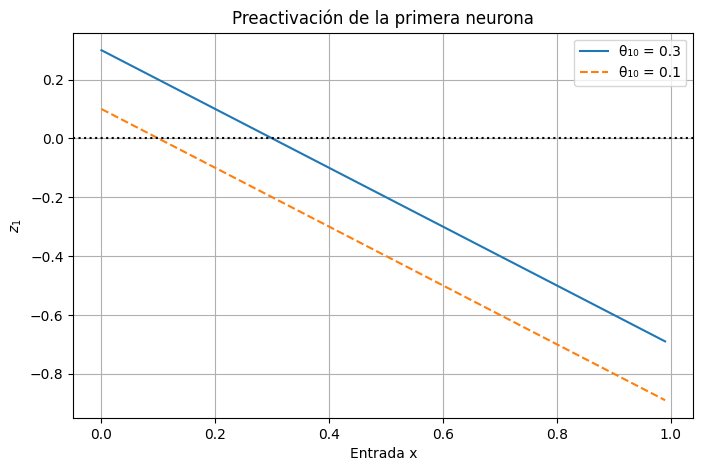

In [64]:
# Obtener las preactivaciones

_, pre1_original, _, _, _, _, _, _, _, _ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    0.3, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

_, pre1_modificada, _, _, _, _, _, _, _, _ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    0.1, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x, pre1_original, label='θ₁₀ = 0.3')
plt.plot(x, pre1_modificada, '--', label='θ₁₀ = 0.1')

plt.axhline(0,color='black',linestyle=':')

plt.title("Preactivación de la primera neurona")
plt.xlabel("Entrada x")
plt.ylabel("$z_1$")
plt.grid(True)
plt.legend()

plt.show()

Con los parámetros originales:

**z1 0.3−x**

La neurona deja de activarse cuando

**0.3−x=0**

es decir,

**x=0.3.**

Al cambiar

theta_10 = 0.1

la ecuación queda:

**z1=0.1−x**

y ahora la neurona deja de activarse en

**x=0.1**.

Ese cambio hace que el primer joint se mueva hacia la izquierda. Al ya no coincidir con el comportamiento de las demás neuronas, desaparece el tramo horizontal y todos los segmentos de la función presentan una pendiente distinta de cero.

####7. What do you predict would happen if you multiply theta_20 and theta21 by 0.5, and phi_2 by 2.0?  Check if you are correct


Comparando la red original con la red modificada y además mostrar la contribución de la segunda neurona.

La salida de la red prácticamente no cambia.


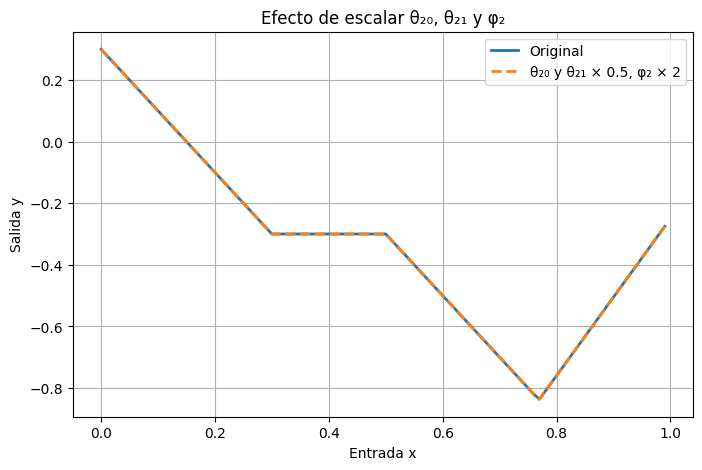

In [65]:
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

x = np.arange(0,1,0.01)

# Red original
y_original, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

# Red modificada
y_modificada, *_ = shallow_1_1_3(
    x, ReLU,
    phi_0,
    phi_1,
    phi_2 * 2,          # φ2 × 2
    phi_3,
    theta_10,
    theta_11,
    theta_20 * 0.5,     # θ20 × 0.5
    theta_21 * 0.5,     # θ21 × 0.5
    theta_30,
    theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x, y_original, linewidth=2, label="Original")
plt.plot(x, y_modificada, "--", linewidth=2,
         label="θ₂₀ y θ₂₁ × 0.5, φ₂ × 2")

plt.title("Efecto de escalar θ₂₀, θ₂₁ y φ₂")
plt.xlabel("Entrada x")
plt.ylabel("Salida y")
plt.grid(True)
plt.legend()

plt.show()

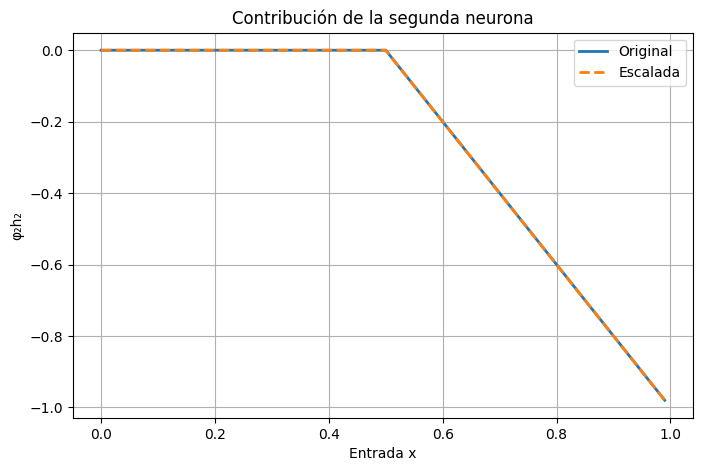

In [66]:
# Obtener únicamente la contribución de la segunda neurona

_, _, _, _, _, _, _, _, w2_original, _ = shallow_1_1_3(
    x, ReLU,
    phi_0, phi_1, phi_2, phi_3,
    theta_10, theta_11,
    theta_20, theta_21,
    theta_30, theta_31
)

_, _, _, _, _, _, _, _, w2_modificada, _ = shallow_1_1_3(
    x, ReLU,
    phi_0,
    phi_1,
    phi_2 * 2,
    phi_3,
    theta_10,
    theta_11,
    theta_20 * 0.5,
    theta_21 * 0.5,
    theta_30,
    theta_31
)

plt.figure(figsize=(8,5))

plt.plot(x, w2_original, linewidth=2, label="Original")
plt.plot(x, w2_modificada, "--", linewidth=2,
         label="Escalada")

plt.title("Contribución de la segunda neurona")
plt.xlabel("Entrada x")
plt.ylabel("φ₂h₂")
plt.grid(True)
plt.legend()

plt.show()

La segunda neurona calcula:

**h₂=ReLU(θ₂₀ + θ₂₁x)**

Si multiplicamos θ₂₀ y θ₂₁ por 0.5, obtenemos:

**h₂=ReLU (1/2(θ₂₀ + θ₂₁x))**

Como la función ReLU cumple que, para factores positivos,

**ReLU(az)=aReLU(z) (a>0)**,

entonces:

**h₂ = 1/2(ReLU(θ₂₀ + θ₂₁x)**

Es decir, la activación de la neurona se reduce exactamente a la mitad.

Posteriormente, esa activación se multiplica por el peso de salida:

ϕ₂h₂

Si ahora hacemos:

**ϕ₂→2ϕ₂,**

el resultado es:

**(2ϕ₂)(1/2(h₂)) = ϕ₂h₂**

Por ello, la contribución de la segunda neurona permanece prácticamente igual, y como las demás neuronas no cambian, la salida de la red también se mantiene prácticamente igual.

#### 8. What do you predict would happen if you multiply theta_20 and theta21 by -0.5, and phi_2 by -2.0? Check if you are correct.

La salida cambia considerablemente.

Aunque el producto final parece compensarse,

**(−2)(−0.5)=1**

la función ReLU no es lineal.

Al cambiar el signo de los parámetros internos,

**z2→−0.5 z2**
	​
los valores positivos pasan a negativos y viceversa.

Como ReLU elimina todos los valores negativos,

**ReLU(−z) ≠ -ReLU(z)**

Por ello la neurona se activa en regiones completamente distintas y la forma de la curva cambia.

theta_10 =  0.3 ; theta_11 = -1.0

theta_20 = -1.0  ; theta_21 = 2.0

theta_30 = -0.5  ; theta_31 = 0.65

phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

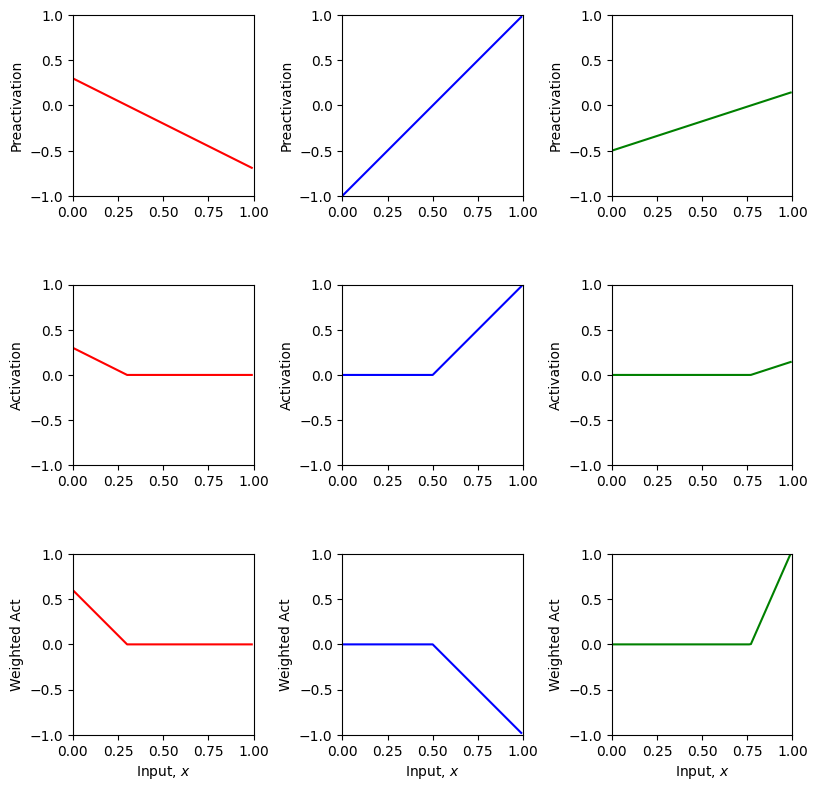

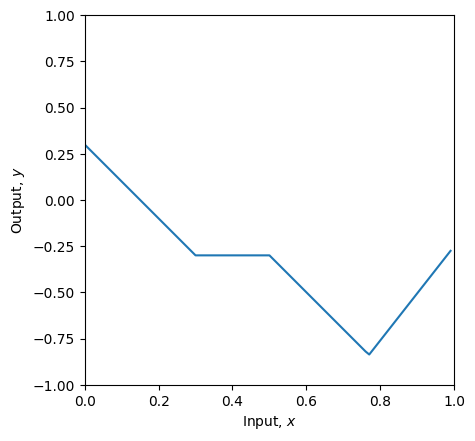

In [67]:
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_0 = -0.3
phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

x = np.arange(0,1,0.01)

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(
        x, ReLU,
        phi_0, phi_1, phi_2, phi_3,
        theta_10, theta_11,
        theta_20, theta_21,
        theta_30, theta_31
    )

plot_neural(
    x,
    y,
    pre_1,
    pre_2,
    pre_3,
    act_1,
    act_2,
    act_3,
    w_act_1,
    w_act_2,
    w_act_3,
    plot_all=True
)

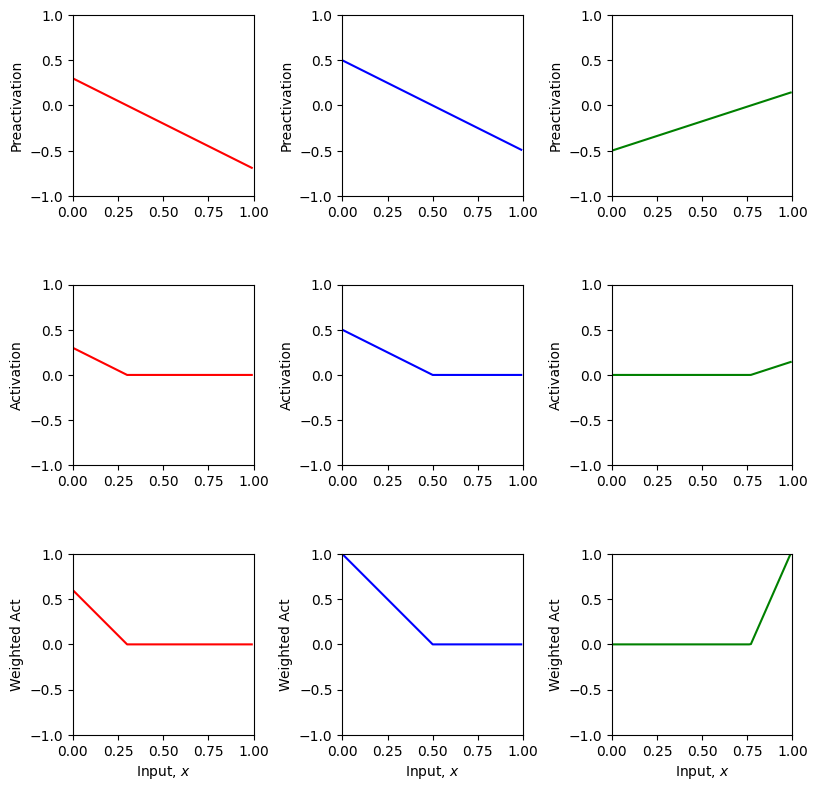

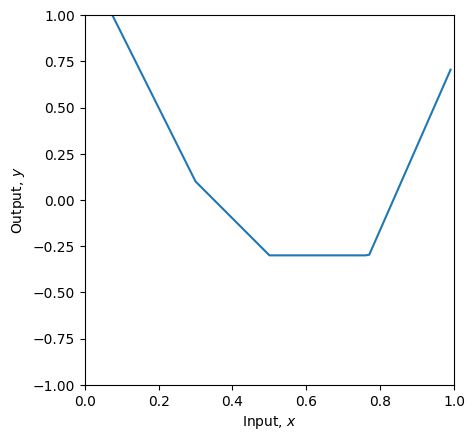

In [68]:
#segunda neurona
theta_20 = theta_20 * (-0.5)
theta_21 = theta_21 * (-0.5)
phi_2 = phi_2 * (-2)

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(
        x, ReLU,
        phi_0, phi_1, phi_2, phi_3,
        theta_10, theta_11,
        theta_20, theta_21,
        theta_30, theta_31
    )

plot_neural(
    x,
    y,
    pre_1,
    pre_2,
    pre_3,
    act_1,
    act_2,
    act_3,
    w_act_1,
    w_act_2,
    w_act_3,
    plot_all=True
)

### Se muestra que las curvas ya no coinciden, sino que cambian considerablemente.
####Como consecuencia, los valores que antes eran positivos ahora son negativos y viceversa. Dado que la función ReLU elimina todos los valores negativos, la neurona comienza a activarse en regiones diferentes del dominio.

Esto demuestra que el cambio no se debe únicamente al peso φ₂, sino a que la función ReLU no es lineal.
Si fuera una función lineal, el escalamiento negativo se compensaría; sin embargo, como la ReLU elimina todos los valores negativos, invertir el signo de la preactivación hace que la neurona se active en regiones completamente distintas, modificando toda la salida de la red.

##### 1. Predict what effect changing phi_0 will have on the network.


#####2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct


##### 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.


##### 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.


##### 5. Change the parameters so that there are only two "joints" (including outside the range of the plot)

##### There are actually three ways to do this.



##### 6. With the original parameters, the second line segment is flat (i.e. has slope zero)
#####How could you change theta_10 so that all of the segments have non-zero slopes


##### 7. What do you predict would happen if you multiply theta_20 and theta21 by 0.5, and phi_2 by 2.0?
##### Check if you are correct.


##### 8. What do you predict would happen if you multiply theta_20 and theta21 by -0.5, and phi_2 by -2.0?
##### Check if you are correct.


#### Define a range of input values
x = np.arange(0,1,0.01)

###### We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
###### And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

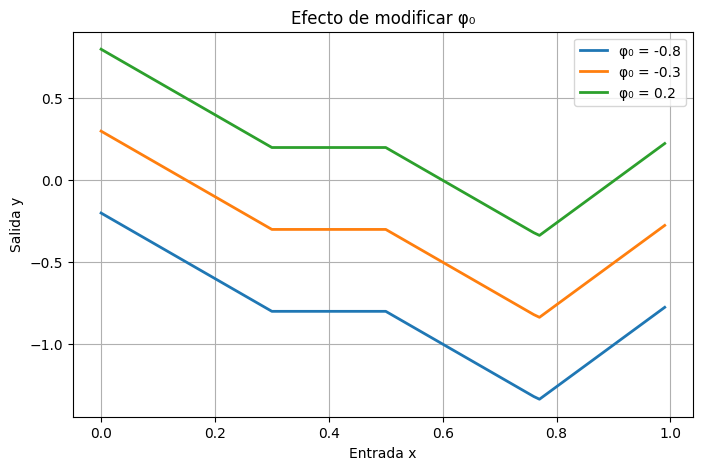

In [69]:
# Parámetros originales
theta_10 = 0.3
theta_11 = -1.0
theta_20 = -1.0
theta_21 = 2.0
theta_30 = -0.5
theta_31 = 0.65

phi_1 = 2.0
phi_2 = -1.0
phi_3 = 7.0

# Valores de entrada
x = np.arange(0, 1, 0.01)

# Distintos valores para el bias de salida
phi0_values = [-0.8, -0.3, 0.2]

plt.figure(figsize=(8,5))

for phi_0 in phi0_values:

    y, *_ = shallow_1_1_3(
        x, ReLU,
        phi_0, phi_1, phi_2, phi_3,
        theta_10, theta_11,
        theta_20, theta_21,
        theta_30, theta_31
    )

    plt.plot(x, y, linewidth=2, label=f'φ₀ = {phi_0}')

plt.title("Efecto de modificar φ₀")
plt.xlabel("Entrada x")
plt.ylabel("Salida y")
plt.grid(True)
plt.legend()
plt.show()

# Least squares loss

Now let's consider fitting the network to data.  First we need to define the loss function.  We'll use the least squares loss:

\begin{equation}
L[\boldsymbol\phi] = \sum_{i=1}^{I}(y_{i}-\text{f}[x_{i},\boldsymbol\phi])^2
\end{equation}

where $(x_i,y_i)$ is an input/output training pair and $\text{f}[\bullet,\boldsymbol\phi]$ is the neural network with parameters $\boldsymbol\phi$.  The first term in the brackets is the ground truth output and the second term is the prediction of the model

In [70]:
# Least squares function
def least_squares_loss(y_train, y_predict):
  # TODO Replace the line below to compute the sum of squared
  # differences between the real values of y and the predicted values from the model f[x_i,phi]
  # you will need to use the function np.sum
  loss = np.sum((y_train - y_predict) ** 2)

  return loss

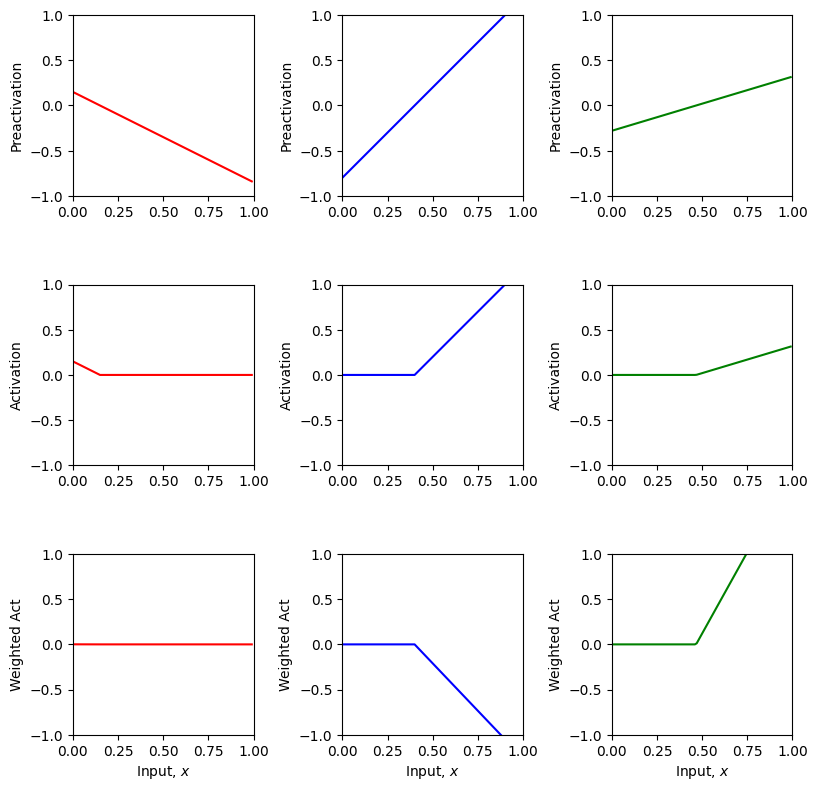

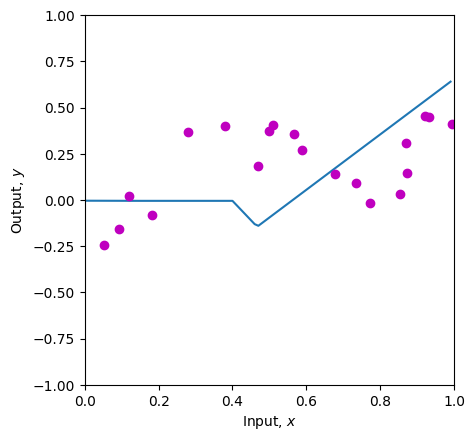

Your Loss = 1.623


In [71]:
# Now lets define some parameters, run the neural network, and compute the loss
theta_10 =  0.15 ; theta_11 = -1.0
theta_20 = -0.8  ; theta_21 = 2.0
theta_30 = -0.28  ; theta_31 = 0.6
phi_0 = -0.005; phi_1 = .005; phi_2 = -1.05; phi_3 = 6

# Define a range of input values
x = np.arange(0,1,0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

# Run the neural network on the training data
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute the least squares loss and print it out
loss = least_squares_loss(y_train,y_predict)
print('Your Loss = %3.3f'%(loss))

# TODO.  Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible.  The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this! Computers are best than human at this, so don't worry about it.

In [72]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3):

  fig, ax = plt.subplots(3,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_1); ax[2,0].set_title('Weighted Act')
  draw_2D_function(ax[2,1], x1,x2,w_act_2); ax[2,1].set_title('Weighted Act')
  draw_2D_function(ax[2,2], x1,x2,w_act_3); ax[2,2].set_title('Weighted Act')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y)
  ax.set_title('Network output, $y$')
  ax.set_aspect(1.0)
  plt.show()

In [73]:
# Define a shallow neural network with two inputs, one output, and three hidden units
def shallow_2_1_3(x1, x2, activation_fn,
                  phi_0, phi_1, phi_2, phi_3,
                  theta_10, theta_11, theta_12,
                  theta_20, theta_21, theta_22,
                  theta_30, theta_31, theta_32):

# TODO Replace the lines below to compute the three initial linear functions
    pre_1 = theta_10 + theta_11*x1 + theta_12*x2
    pre_2 = theta_20 + theta_21*x1 + theta_22*x2
    pre_3 = theta_30 + theta_31*x1 + theta_32*x2

# Pass these through the ReLU function to compute the activations as in
    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

   # TODO Replace the code below to weight the activations using phi1, phi2 and phi3
    w_act_1 = phi_1 * act_1
    w_act_2 = phi_2 * act_2
    w_act_3 = phi_3 * act_3

   # TODO Replace the code below to combing the weighted activations and add
    y = phi_0 + w_act_1 + w_act_2 + w_act_3
 # Return everything we have calculated
    return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

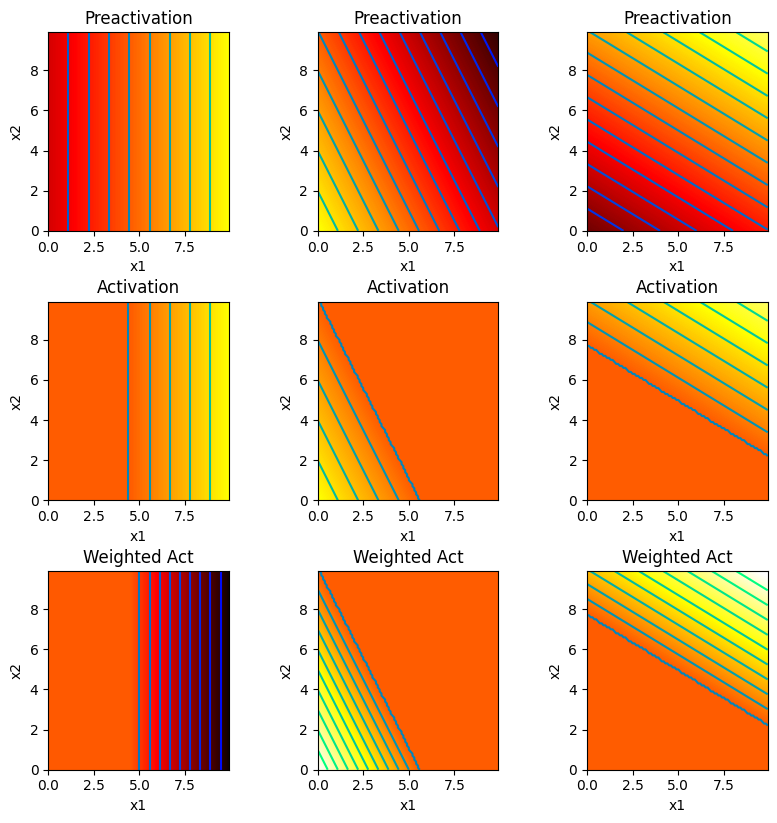

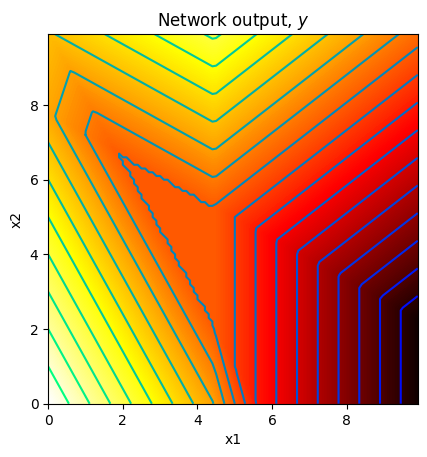

In [74]:
# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_0 = 0.0; phi_1 = -2.0; phi_2 = 2.0; phi_3 = 1.5

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_2_1_3(x1,x2, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# And then plot it
plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3)

Cada neurona calcula una combinación lineal de las entradas utilizando sus pesos y su sesgo. Este valor recibe el nombre de preactivación, ya que posteriormente será procesado por la función de activación.
La función de activación introduce la no linealidad en la red neuronal. En esta práctica se utiliza la función ReLU.

Cada activación es multiplicada por el peso correspondiente de la capa de salida. De esta manera se obtiene la contribución individual de cada neurona a la salida final.

La salida de la red se obtiene sumando el sesgo de salida y las contribuciones de las tres neuronas ocultas.
###**y = phi_0 + w_act_1 + w_act_2 + w_act_3**

How many different linear polytopes are made by this model?  Identify each in the network output.

Now we'll extend this model to have two outputs $y_1$ and $y_2$, each of which can be visualized with a separate heatmap.  You will now have sets of parameters $\phi_{10}, \phi_{11}, \phi_{12}, \phi_{13}$ and $\phi_{20}, \phi_{21}, \phi_{22}, \phi_{23}$ that correspond to each of these outputs.

In [75]:
# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23):

  # Plot intermediate plots if flag set
  fig, ax = plt.subplots(4,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_11); ax[2,0].set_title('Weighted Act 1')
  draw_2D_function(ax[2,1], x1,x2,w_act_12); ax[2,1].set_title('Weighted Act 1')
  draw_2D_function(ax[2,2], x1,x2,w_act_13); ax[2,2].set_title('Weighted Act 1')
  draw_2D_function(ax[3,0], x1,x2,w_act_21); ax[3,0].set_title('Weighted Act 2')
  draw_2D_function(ax[3,1], x1,x2,w_act_22); ax[3,1].set_title('Weighted Act 2')
  draw_2D_function(ax[3,2], x1,x2,w_act_23); ax[3,2].set_title('Weighted Act 2')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y1)
  ax.set_title('Network output, $y_1$')
  ax.set_aspect(1.0)
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y2)
  ax.set_title('Network output, $y_2$')
  ax.set_aspect(1.0)
  plt.show()

In [82]:
# Define a shallow neural network with, two inputs, two outputs, and three hidden units
def shallow_2_2_3(x1,x2, activation_fn,
                  phi_10,phi_11,phi_12,phi_13,
                  phi_20,phi_21,phi_22,phi_23,
                  theta_10,theta_11,theta_12,
                  theta_20,theta_21,theta_22,
                  theta_30,theta_31,theta_32):
  # TODO -- write this function -- replace the dummy code below
    # Preactivaciones
    pre_1 = theta_10 + theta_11*x1 + theta_12*x2
    pre_2 = theta_20 + theta_21*x1 + theta_22*x2
    pre_3 = theta_30 + theta_31*x1 + theta_32*x2

    # Activaciones
    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    # Contribuciones para la salida y1
    w_act_11 = phi_11 * act_1
    w_act_12 = phi_12 * act_2
    w_act_13 = phi_13 * act_3

    # Contribuciones para la salida y2
    w_act_21 = phi_21 * act_1
    w_act_22 = phi_22 * act_2
    w_act_23 = phi_23 * act_3

    # Salidas finales
    y1 = phi_10 + w_act_11 + w_act_12 + w_act_13
    y2 = phi_20 + w_act_21 + w_act_22 + w_act_23

    # Return everything we have calculated
    return (y1, y2, pre_1, pre_2, pre_3,
            act_1, act_2, act_3,
            w_act_11, w_act_12, w_act_13,
            w_act_21, w_act_22, w_act_23)


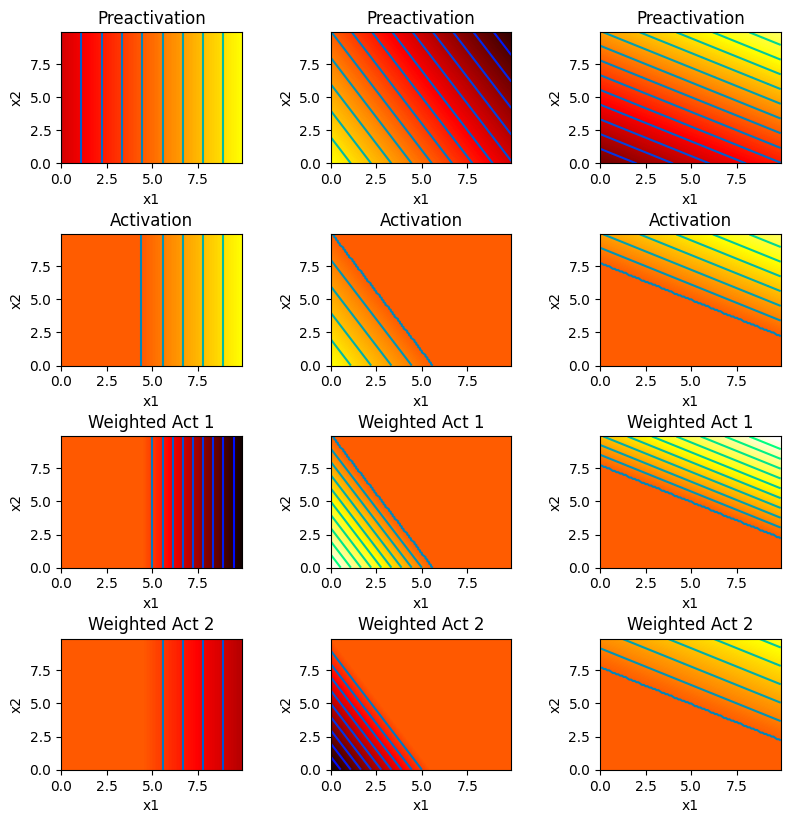

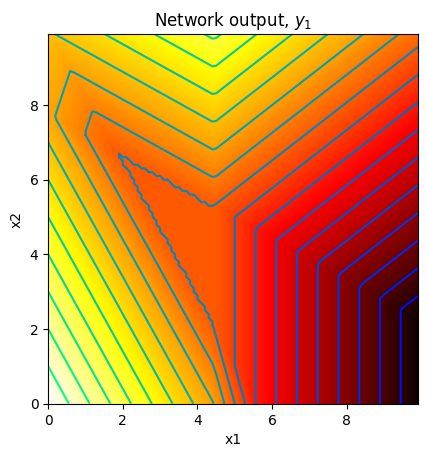

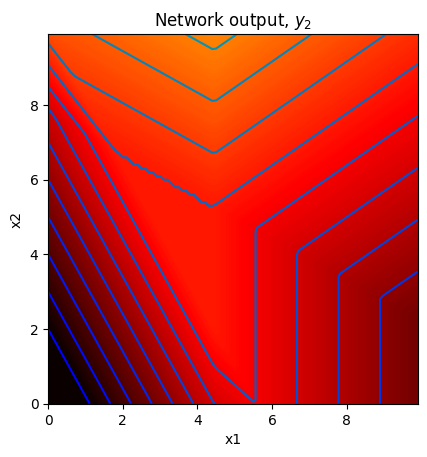

In [81]:
# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_10 = 0.0; phi_11 = -2.0; phi_12 = 2.0; phi_13 = 1.5
phi_20 = -2.0; phi_21 = -1.0; phi_22 = -2.0; phi_23 = 0.8

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# We run the neural network for each of these input values
y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23 = \
    shallow_2_2_3(x1,x2, ReLU, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# And then plot it
plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23)

Se implementaron las mismas ecuaciones utilizadas en el ejercicio anterior.

pre_1 = theta_10 + theta_11*x1 + theta_12*x2

pre_2 = theta_20 + theta_21*x1 + theta_22*x2

pre_3 = theta_30 + theta_31*x1 + theta_32*x2

Las neuronas ocultas son compartidas por ambas salidas, por lo que únicamente se calculan una vez.

Cada preactivación es transformada mediante la función ReLU para producir la salida de cada neurona oculta.

Se calcularon las contribuciones individuales de las tres neuronas hacia la primera salida de la red.

w_act_11 = phi_11 * act_1

w_act_12 = phi_12 * act_2

w_act_13 = phi_13 * act_3

De forma análoga, se calcularon las contribuciones correspondientes a la segunda salida utilizando un conjunto distinto de pesos.

w_act_21 = phi_21 * act_1

w_act_22 = phi_22 * act_2

w_act_23 = phi_23 * act_3


Cada salida se obtiene sumando el sesgo correspondiente y las contribuciones ponderadas de las tres neuronas ocultas.

###**y1 = phi_10 + w_act_11 + w_act_12 + w_act_13**

###**y2 = phi_20 + w_act_21 + w_act_22 + w_act_23**

En esta práctica se implementó el funcionamiento interno de una red neuronal superficial (Shallow Neural Network) sustituyendo el código temporal por las ecuaciones correspondientes al cálculo de las preactivaciones, activaciones y salidas. Posteriormente, se amplió la arquitectura para generar dos salidas independientes utilizando la misma capa oculta. Finalmente, mediante las funciones de visualización fue posible analizar gráficamente cómo cada neurona contribuye a la construcción de la función de salida, permitiendo comprender el proceso de propagación hacia adelante (forward propagation) dentro de una red neuronal.